In [1]:

from sklearn.datasets import load_iris
iris = load_iris()
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df['target'].value_counts())


target
0    50
1    50
2    50
Name: count, dtype: int64


In [2]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


<Axes: >

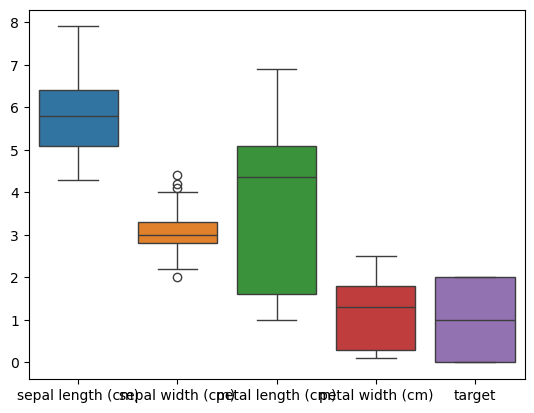

In [4]:
import seaborn as sns
sns.boxplot(data=df)

In [5]:
def cap_outliers(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return df[column].clip(lower_bound, upper_bound)

df['sepal width (cm)']=cap_outliers('sepal width (cm)')

<Axes: >

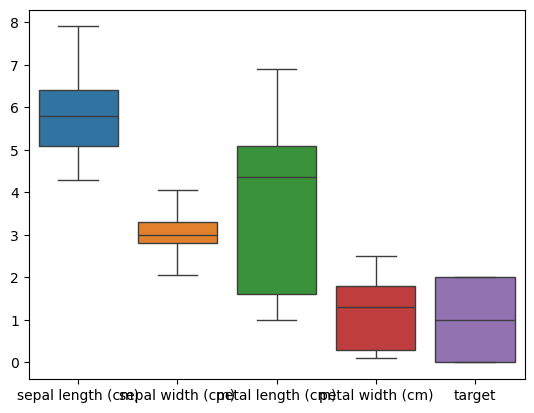

In [6]:
sns.boxplot(data=df)

In [7]:
x=df.drop(columns=["target"])
y=df['target']

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.neighbors import KNeighborsClassifier
knn_classifier = KNeighborsClassifier(n_neighbors=3,metric='hamming')
knn_classifier.fit(x_train,y_train)
y_pred = knn_classifier.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))

Accuracy: 0.7666666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       0.67      0.89      0.76         9
           2       1.00      0.45      0.62        11

    accuracy                           0.77        30
   macro avg       0.81      0.78      0.75        30
weighted avg       0.82      0.77      0.75        30

Confusion Matrix:
 [[10  0  0]
 [ 1  8  0]
 [ 2  4  5]]
